# Training Infrastructure Demo

This notebook demonstrates the training infrastructure implemented in M19:
- **TrainerConfig**: Configuration for training hyperparameters
- **Loss Functions**: MSE, Huber, Quantile, and MaskedLoss
- **Evaluation Metrics**: IC, Rank IC, RMSE, MAE
- **Training Loop**: Early stopping, gradient clipping, LR scheduling
- **Checkpointing**: Save/load model state

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from src.models import (
    # Graph
    SurfaceGraphConfig, build_surface_graph,
    # Models
    PatchTSTModelConfig, GNNModelConfig, PatchTST_GNN_Ensemble,
    # Training
    Trainer, TrainerConfig, TrainResult,
    HuberLoss, QuantileLoss, MaskedLoss, build_loss,
    surface_collate_fn,
    # Metrics
    compute_ic, compute_rank_ic, compute_rmse, compute_mae, MetricsCalculator,
)

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1
MPS available: True
CUDA available: False


## 1. Loss Functions

We provide several loss functions for different use cases:
- **MSE**: Standard mean squared error
- **Huber**: Robust to outliers (quadratic for small errors, linear for large)
- **Quantile**: For uncertainty estimation (asymmetric penalties)
- **MaskedLoss**: Wrapper to handle invalid nodes

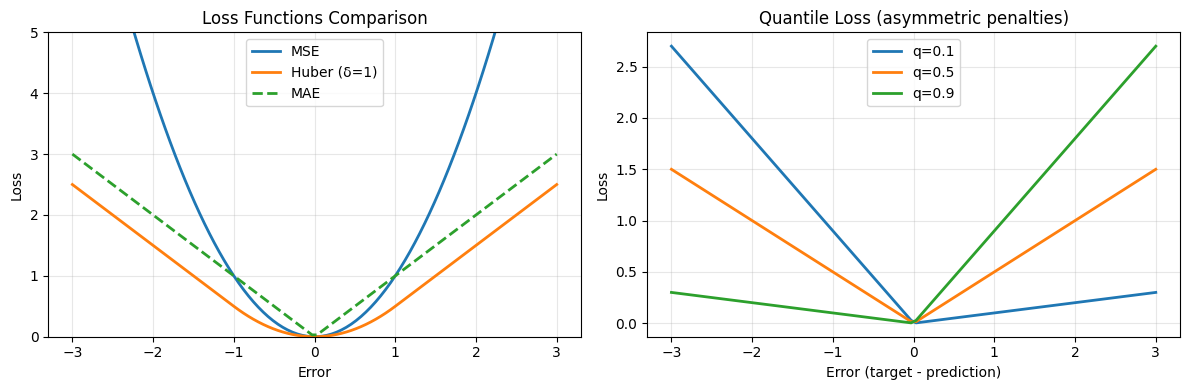

Huber loss transitions from quadratic to linear at δ=1
Quantile loss penalizes over/under-estimation asymmetrically


In [2]:
# Compare loss functions
errors = torch.linspace(-3, 3, 100)

mse_loss = torch.nn.MSELoss(reduction='none')
huber_loss = HuberLoss(delta=1.0, reduction='none')
mae_loss = torch.nn.L1Loss(reduction='none')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss values
ax = axes[0]
ax.plot(errors.numpy(), mse_loss(errors, torch.zeros_like(errors)).numpy(), label='MSE', linewidth=2)
ax.plot(errors.numpy(), huber_loss(errors, torch.zeros_like(errors)).numpy(), label='Huber (δ=1)', linewidth=2)
ax.plot(errors.numpy(), mae_loss(errors, torch.zeros_like(errors)).numpy(), label='MAE', linewidth=2, linestyle='--')
ax.set_xlabel('Error')
ax.set_ylabel('Loss')
ax.set_title('Loss Functions Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)

# Quantile loss for different quantiles
ax = axes[1]
for q in [0.1, 0.5, 0.9]:
    ql = QuantileLoss(quantile=q, reduction='none')
    losses = ql(torch.zeros_like(errors), errors)  # pred=0, target=error
    ax.plot(errors.numpy(), losses.numpy(), label=f'q={q}', linewidth=2)
ax.set_xlabel('Error (target - prediction)')
ax.set_ylabel('Loss')
ax.set_title('Quantile Loss (asymmetric penalties)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Huber loss transitions from quadratic to linear at δ=1")
print("Quantile loss penalizes over/under-estimation asymmetrically")

In [3]:
# Demonstrate MaskedLoss
base_loss = torch.nn.MSELoss()
masked_loss = MaskedLoss(base_loss)

# Create sample data with some invalid nodes
preds = torch.tensor([[[1.0, 2.0], [3.0, 4.0], [100.0, 200.0]]])  # batch=1, nodes=3, horizons=2
targets = torch.tensor([[[1.0, 2.0], [3.0, 4.0], [0.0, 0.0]]])    # Large error in node 2
mask = torch.tensor([[True, True, False]])  # Node 2 is invalid

# Without mask - large error from node 2
loss_unmasked = base_loss(preds, targets)
# With mask - only valid nodes contribute
loss_masked = masked_loss(preds, targets, mask)

print(f"Unmasked MSE: {loss_unmasked.item():.4f} (includes invalid node with large error)")
print(f"Masked MSE:   {loss_masked.item():.4f} (only valid nodes, should be ~0)")

Unmasked MSE: 8333.3330 (includes invalid node with large error)
Masked MSE:   0.0000 (only valid nodes, should be ~0)


## 2. Evaluation Metrics

Key metrics for evaluating volatility predictions:
- **IC (Information Coefficient)**: Pearson correlation between predictions and targets
- **Rank IC**: Spearman correlation (robust to outliers)
- **RMSE**: Root mean squared error
- **MAE**: Mean absolute error

In [4]:
# Generate sample predictions with different quality levels
np.random.seed(42)
n_samples = 100
n_horizons = 3

targets = np.random.randn(n_samples, n_horizons)

# Good predictions (high correlation)
good_preds = targets + 0.1 * np.random.randn(n_samples, n_horizons)

# Mediocre predictions (moderate correlation)
mediocre_preds = targets + 0.5 * np.random.randn(n_samples, n_horizons)

# Poor predictions (low correlation)
poor_preds = np.random.randn(n_samples, n_horizons)

# Compute metrics
calc = MetricsCalculator()

print("Metrics Comparison:")
print("-" * 60)
print(f"{'Prediction Quality':<20} {'IC':>10} {'Rank IC':>10} {'RMSE':>10} {'MAE':>10}")
print("-" * 60)

for name, preds in [('Good', good_preds), ('Mediocre', mediocre_preds), ('Poor', poor_preds)]:
    metrics = calc.compute_all(preds, targets)
    print(f"{name:<20} {metrics['ic']:>10.4f} {metrics['rank_ic']:>10.4f} {metrics['rmse']:>10.4f} {metrics['mae']:>10.4f}")

Metrics Comparison:
------------------------------------------------------------
Prediction Quality           IC    Rank IC       RMSE        MAE
------------------------------------------------------------
Good                     0.9949     0.9920     0.0960     0.0767
Mediocre                 0.8883     0.8820     0.4992     0.3999
Poor                     0.0641     0.0708     1.3628     1.0604


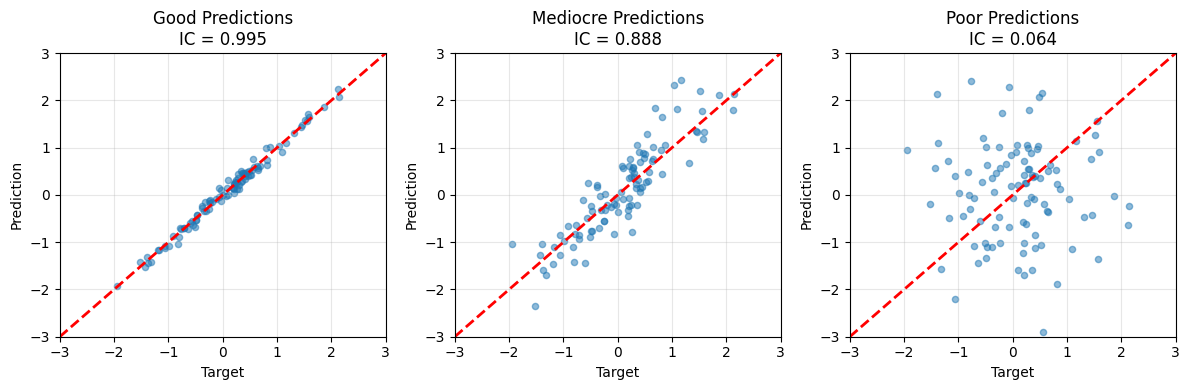

In [5]:
# Visualize correlation
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [('Good', good_preds), ('Mediocre', mediocre_preds), ('Poor', poor_preds)]):
    # Plot first horizon
    ax.scatter(targets[:, 0], preds[:, 0], alpha=0.5, s=20)
    ax.plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='Perfect')
    
    ic = compute_ic(preds, targets)
    ax.set_title(f'{name} Predictions\nIC = {ic:.3f}')
    ax.set_xlabel('Target')
    ax.set_ylabel('Prediction')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Synthetic Dataset

Create a synthetic dataset for training demonstration.

In [6]:
class SyntheticSurfaceDataset(Dataset):
    """Synthetic dataset mimicking volatility surface data."""
    
    def __init__(self, num_samples: int, num_nodes: int, time_steps: int = 22,
                 num_features: int = 13, num_horizons: int = 3):
        self.num_samples = num_samples
        
        # Generate features with some temporal structure
        self.X = torch.randn(num_samples, time_steps, num_nodes, num_features)
        
        # Target is a function of recent features (learnable pattern)
        # Using last time step features + noise
        self.y = self.X[:, -1, :, :num_horizons].clone() + 0.1 * torch.randn(num_samples, num_nodes, num_horizons)
        
        # All nodes valid
        self.mask = torch.ones(num_samples, num_nodes, dtype=torch.bool)
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return {
            'X': self.X[idx],
            'y': self.y[idx],
            'mask': self.mask[idx],
        }

# Build graph
graph_config = SurfaceGraphConfig()
graph = build_surface_graph(graph_config)
print(f"Surface graph: {graph.num_nodes} nodes, {graph.edge_index.shape[1]} edges")

# Create datasets
train_dataset = SyntheticSurfaceDataset(num_samples=256, num_nodes=graph.num_nodes)
val_dataset = SyntheticSurfaceDataset(num_samples=64, num_nodes=graph.num_nodes)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=surface_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=surface_collate_fn)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")

Surface graph: 42 nodes, 142 edges
Train: 256 samples, 8 batches
Val:   64 samples, 2 batches


## 4. Model and Trainer Setup

In [7]:
# Create ensemble model
patchtst_config = PatchTSTModelConfig(
    d_model=64,
    n_layers=2,
    n_heads=4,
    dropout=0.1,
)

gnn_config = GNNModelConfig(
    model_type='GAT',
    hidden_dim=32,
    n_layers=2,
    heads=4,
    dropout=0.1,
)

model = PatchTST_GNN_Ensemble(
    patchtst_config=patchtst_config,
    gnn_config=gnn_config,
    input_dim=13,
    output_horizons=3,
)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 130,147


In [8]:
# Configure trainer
trainer_config = TrainerConfig(
    device='auto',  # Will use MPS on Mac, CUDA on GPU, else CPU
    batch_size=32,
    max_epochs=20,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=5,
    early_stopping_metric='rank_ic',
    early_stopping_mode='max',
    gradient_clip_val=1.0,
    loss_type='mse',
    scheduler_type='cosine',
    scheduler_warmup_epochs=3,
    checkpoint_dir='../artifacts/checkpoints/demo',
    log_every_n_steps=5,
)

print("TrainerConfig:")
for key, value in trainer_config.__dict__.items():
    print(f"  {key}: {value}")

TrainerConfig:
  device: auto
  batch_size: 32
  max_epochs: 20
  learning_rate: 0.001
  weight_decay: 1e-05
  early_stopping_patience: 5
  early_stopping_metric: rank_ic
  early_stopping_mode: max
  gradient_clip_val: 1.0
  checkpoint_dir: ../artifacts/checkpoints/demo
  loss_type: mse
  huber_delta: 1.0
  quantile: 0.5
  scheduler_type: cosine
  scheduler_warmup_epochs: 3
  scheduler_step_size: 10
  scheduler_gamma: 0.1
  log_every_n_steps: 5


## 5. Training Loop

In [9]:
# Create trainer and run training
trainer = Trainer(model, trainer_config, graph)

print("Starting training...")
print("=" * 60)
result = trainer.train(train_loader, val_loader)
print("=" * 60)
print(f"\nTraining complete!")
print(f"  Epochs trained: {result.epochs_trained}")
print(f"  Best epoch: {result.best_epoch + 1}")
print(f"  Best Rank IC: {result.best_val_metric:.4f}")

2026-01-23 01:36:09.789 | INFO     | src.models.train.trainer:__init__:129 - Using device: mps
2026-01-23 01:36:09.801 | INFO     | src.models.train.trainer:train:240 - Starting training for up to 20 epochs


Starting training...


2026-01-23 01:36:12.447 | DEBUG    | src.models.train.trainer:_train_epoch:358 - Epoch 1, Batch 5/8, Loss: 1.0497
2026-01-23 01:36:14.010 | DEBUG    | src.models.train.trainer:save_checkpoint:457 - Saved checkpoint to ../artifacts/checkpoints/demo/best_model.pt
2026-01-23 01:36:14.011 | INFO     | src.models.train.trainer:train:279 - Epoch 1/20 - Train Loss: 1.0323, Val Loss: 1.0291, IC: -0.0052, Rank IC: -0.0046, LR: 1.00e-04
2026-01-23 01:36:15.612 | DEBUG    | src.models.train.trainer:_train_epoch:358 - Epoch 2, Batch 5/8, Loss: 1.0422
2026-01-23 01:36:17.066 | INFO     | src.models.train.trainer:train:279 - Epoch 2/20 - Train Loss: 1.0197, Val Loss: 1.0192, IC: -0.0158, Rank IC: -0.0138, LR: 4.00e-04
2026-01-23 01:36:18.641 | DEBUG    | src.models.train.trainer:_train_epoch:358 - Epoch 3, Batch 5/8, Loss: 0.9878
2026-01-23 01:36:20.320 | INFO     | src.models.train.trainer:train:279 - Epoch 3/20 - Train Loss: 1.0144, Val Loss: 1.0175, IC: -0.0102, Rank IC: -0.0081, LR: 7.00e-04
202


Training complete!
  Epochs trained: 9
  Best epoch: 4
  Best Rank IC: -0.0041


## 6. Training Curves

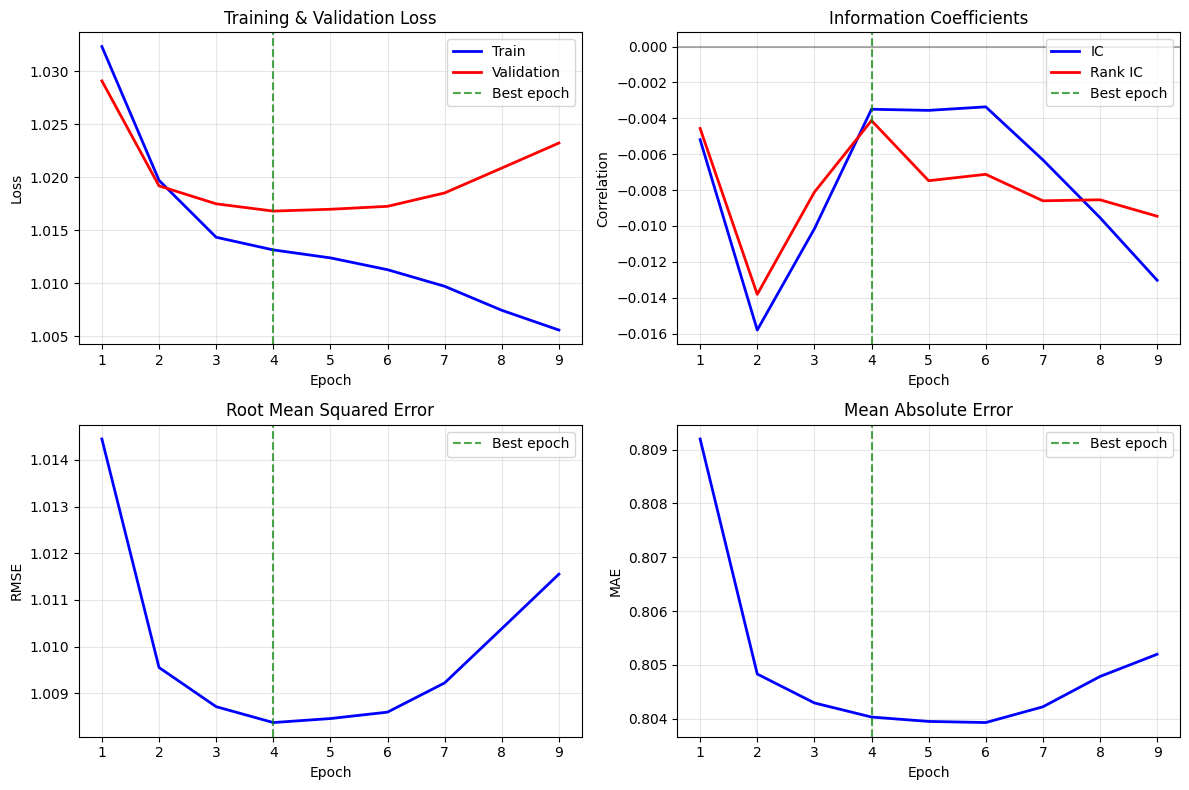

In [10]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

epochs = range(1, result.epochs_trained + 1)

# Loss curves
ax = axes[0, 0]
ax.plot(epochs, result.train_losses, 'b-', label='Train', linewidth=2)
ax.plot(epochs, result.val_losses, 'r-', label='Validation', linewidth=2)
ax.axvline(result.best_epoch + 1, color='g', linestyle='--', alpha=0.7, label='Best epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# IC curves
ax = axes[0, 1]
ics = [m['ic'] for m in result.val_metrics]
rank_ics = [m['rank_ic'] for m in result.val_metrics]
ax.plot(epochs, ics, 'b-', label='IC', linewidth=2)
ax.plot(epochs, rank_ics, 'r-', label='Rank IC', linewidth=2)
ax.axvline(result.best_epoch + 1, color='g', linestyle='--', alpha=0.7, label='Best epoch')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Correlation')
ax.set_title('Information Coefficients')
ax.legend()
ax.grid(True, alpha=0.3)

# RMSE curve
ax = axes[1, 0]
rmses = [m['rmse'] for m in result.val_metrics]
ax.plot(epochs, rmses, 'b-', linewidth=2)
ax.axvline(result.best_epoch + 1, color='g', linestyle='--', alpha=0.7, label='Best epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.set_title('Root Mean Squared Error')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE curve
ax = axes[1, 1]
maes = [m['mae'] for m in result.val_metrics]
ax.plot(epochs, maes, 'b-', linewidth=2)
ax.axvline(result.best_epoch + 1, color='g', linestyle='--', alpha=0.7, label='Best epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('Mean Absolute Error')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Checkpoint Loading

Demonstrate loading a saved checkpoint.

In [11]:
# Create a new model and load the checkpoint
model_loaded = PatchTST_GNN_Ensemble(
    patchtst_config=patchtst_config,
    gnn_config=gnn_config,
    input_dim=13,
    output_horizons=3,
)

# Create a new trainer (needed for loading)
trainer_loaded = Trainer(model_loaded, trainer_config, graph)

# Load the best checkpoint
if result.best_checkpoint_path:
    metrics = trainer_loaded.load_checkpoint(result.best_checkpoint_path)
    print(f"Loaded checkpoint from: {result.best_checkpoint_path}")
    print(f"Checkpoint metrics: {metrics}")
    
    # Verify models produce same output
    model.eval()
    model_loaded.eval()
    
    # Note: We need to load checkpoint into original model too to compare
    # since training continued after best checkpoint was saved
    print("\nModel loaded successfully!")
else:
    print("No checkpoint was saved (training may have been too short)")

2026-01-23 01:36:40.384 | INFO     | src.models.train.trainer:__init__:129 - Using device: mps
2026-01-23 01:36:40.436 | INFO     | src.models.train.trainer:load_checkpoint:477 - Loaded checkpoint from ../artifacts/checkpoints/demo/best_model.pt (epoch 3)


Loaded checkpoint from: ../artifacts/checkpoints/demo/best_model.pt
Checkpoint metrics: {'train_loss': 1.0131540074944496, 'val_loss': 1.0168173909187317, 'ic': -0.0034980730464061103, 'rank_ic': -0.0041286257767039645, 'rmse': 1.0083736181259155, 'mae': 0.8040330410003662}

Model loaded successfully!


## 8. Comparing Loss Functions

Train with different loss functions and compare results.

In [12]:
# Compare different loss functions
results = {}

for loss_type in ['mse', 'huber', 'mae']:
    print(f"\nTraining with {loss_type.upper()} loss...")
    
    # Fresh model
    model_fresh = PatchTST_GNN_Ensemble(
        patchtst_config=patchtst_config,
        gnn_config=gnn_config,
        input_dim=13,
        output_horizons=3,
    )
    
    # Config with this loss type
    config = TrainerConfig(
        device='auto',
        max_epochs=10,
        learning_rate=1e-3,
        early_stopping_patience=10,  # Don't early stop
        loss_type=loss_type,
        scheduler_type='none',
        checkpoint_dir=f'../artifacts/checkpoints/demo_{loss_type}',
        log_every_n_steps=100,  # Quiet
    )
    
    trainer_fresh = Trainer(model_fresh, config, graph)
    results[loss_type] = trainer_fresh.train(train_loader, val_loader)
    
    final_metrics = results[loss_type].val_metrics[-1]
    print(f"  Final Rank IC: {final_metrics['rank_ic']:.4f}, RMSE: {final_metrics['rmse']:.4f}")

2026-01-23 01:36:40.445 | INFO     | src.models.train.trainer:__init__:129 - Using device: mps
2026-01-23 01:36:40.454 | INFO     | src.models.train.trainer:train:240 - Starting training for up to 10 epochs



Training with MSE loss...


2026-01-23 01:36:43.392 | DEBUG    | src.models.train.trainer:save_checkpoint:457 - Saved checkpoint to ../artifacts/checkpoints/demo_mse/best_model.pt
2026-01-23 01:36:43.393 | INFO     | src.models.train.trainer:train:279 - Epoch 1/10 - Train Loss: 1.0135, Val Loss: 1.0170, IC: 0.0120, Rank IC: 0.0049, LR: 1.00e-03
2026-01-23 01:36:46.850 | INFO     | src.models.train.trainer:train:279 - Epoch 2/10 - Train Loss: 1.0137, Val Loss: 1.0166, IC: 0.0052, Rank IC: 0.0018, LR: 1.00e-03
2026-01-23 01:36:50.390 | INFO     | src.models.train.trainer:train:279 - Epoch 3/10 - Train Loss: 1.0126, Val Loss: 1.0165, IC: 0.0022, Rank IC: -0.0024, LR: 1.00e-03
2026-01-23 01:36:53.648 | INFO     | src.models.train.trainer:train:279 - Epoch 4/10 - Train Loss: 1.0118, Val Loss: 1.0166, IC: -0.0004, Rank IC: -0.0022, LR: 1.00e-03
2026-01-23 01:36:57.032 | INFO     | src.models.train.trainer:train:279 - Epoch 5/10 - Train Loss: 1.0105, Val Loss: 1.0169, IC: -0.0004, Rank IC: -0.0022, LR: 1.00e-03
2026-01-

  Final Rank IC: 0.0026, RMSE: 1.0163

Training with HUBER loss...


2026-01-23 01:37:15.703 | DEBUG    | src.models.train.trainer:save_checkpoint:457 - Saved checkpoint to ../artifacts/checkpoints/demo_huber/best_model.pt
2026-01-23 01:37:15.704 | INFO     | src.models.train.trainer:train:279 - Epoch 1/10 - Train Loss: 0.4307, Val Loss: 0.4305, IC: 0.0072, Rank IC: 0.0049, LR: 1.00e-03
2026-01-23 01:37:19.357 | INFO     | src.models.train.trainer:train:279 - Epoch 2/10 - Train Loss: 0.4300, Val Loss: 0.4305, IC: 0.0032, Rank IC: 0.0022, LR: 1.00e-03
2026-01-23 01:37:22.372 | INFO     | src.models.train.trainer:train:279 - Epoch 3/10 - Train Loss: 0.4298, Val Loss: 0.4302, IC: 0.0006, Rank IC: -0.0019, LR: 1.00e-03
2026-01-23 01:37:25.358 | INFO     | src.models.train.trainer:train:279 - Epoch 4/10 - Train Loss: 0.4294, Val Loss: 0.4303, IC: 0.0010, Rank IC: 0.0015, LR: 1.00e-03
2026-01-23 01:37:28.295 | INFO     | src.models.train.trainer:train:279 - Epoch 5/10 - Train Loss: 0.4284, Val Loss: 0.4313, IC: 0.0034, Rank IC: 0.0044, LR: 1.00e-03
2026-01-23

  Final Rank IC: 0.0013, RMSE: 1.0189

Training with MAE loss...


2026-01-23 01:37:46.602 | DEBUG    | src.models.train.trainer:save_checkpoint:457 - Saved checkpoint to ../artifacts/checkpoints/demo_mae/best_model.pt
2026-01-23 01:37:46.602 | INFO     | src.models.train.trainer:train:279 - Epoch 1/10 - Train Loss: 0.8058, Val Loss: 0.8045, IC: 0.0129, Rank IC: 0.0058, LR: 1.00e-03
2026-01-23 01:37:49.636 | INFO     | src.models.train.trainer:train:279 - Epoch 2/10 - Train Loss: 0.8044, Val Loss: 0.8042, IC: 0.0044, Rank IC: -0.0011, LR: 1.00e-03
2026-01-23 01:37:52.703 | INFO     | src.models.train.trainer:train:279 - Epoch 3/10 - Train Loss: 0.8042, Val Loss: 0.8043, IC: 0.0062, Rank IC: 0.0009, LR: 1.00e-03
2026-01-23 01:37:55.743 | INFO     | src.models.train.trainer:train:279 - Epoch 4/10 - Train Loss: 0.8034, Val Loss: 0.8042, IC: 0.0017, Rank IC: -0.0017, LR: 1.00e-03
2026-01-23 01:37:58.680 | INFO     | src.models.train.trainer:train:279 - Epoch 5/10 - Train Loss: 0.8026, Val Loss: 0.8050, IC: 0.0019, Rank IC: -0.0028, LR: 1.00e-03
2026-01-23

  Final Rank IC: 0.0009, RMSE: 1.0182


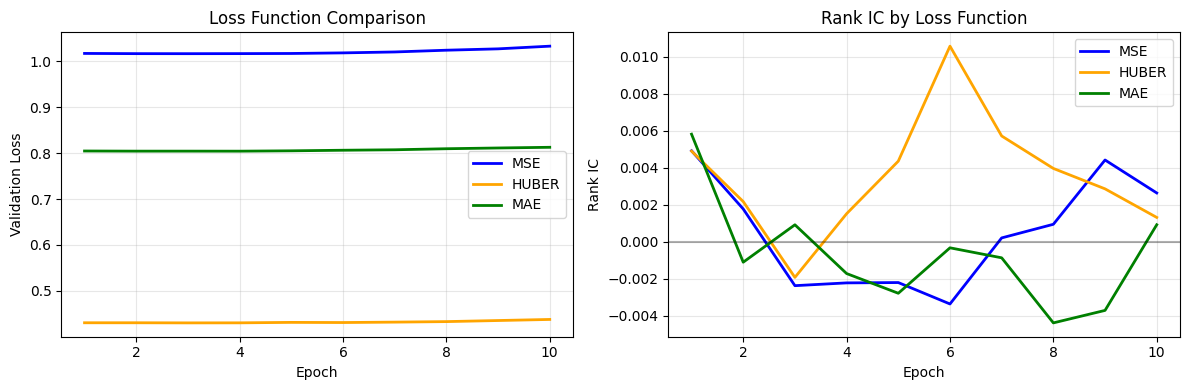

In [13]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'mse': 'blue', 'huber': 'orange', 'mae': 'green'}

# Loss comparison
ax = axes[0]
for loss_type, res in results.items():
    epochs = range(1, res.epochs_trained + 1)
    ax.plot(epochs, res.val_losses, color=colors[loss_type], label=loss_type.upper(), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Loss Function Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Rank IC comparison
ax = axes[1]
for loss_type, res in results.items():
    epochs = range(1, res.epochs_trained + 1)
    rank_ics = [m['rank_ic'] for m in res.val_metrics]
    ax.plot(epochs, rank_ics, color=colors[loss_type], label=loss_type.upper(), linewidth=2)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Rank IC')
ax.set_title('Rank IC by Loss Function')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The training infrastructure provides:

1. **Flexible Loss Functions**: MSE, Huber (robust), Quantile (uncertainty), with MaskedLoss for invalid nodes

2. **Comprehensive Metrics**: IC, Rank IC, RMSE, MAE computed per epoch

3. **Training Features**:
   - Early stopping with configurable patience and metric
   - Gradient clipping for stability
   - LR scheduling (cosine with warmup, step, or none)
   - Automatic device selection (MPS/CUDA/CPU)

4. **Checkpointing**: Save/load model state, optimizer state, scheduler state

5. **CLI Script**: `scripts/train_model.py` for command-line training